In [4]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as path_effects
from matplotlib import rcParams

In [3]:
# --- ANNNI ---
annni_gap   = np.load("GAP_ANNNI.npy")
annni_rrom  = np.load("RRoM_ANNNI.npy")
k_values = np.linspace(0, 1.0, 100)
g_values = np.linspace(0, 1.0, 100)

# --- XXZ ---
xxz_gap  = np.load("GAP_XXZ.npy")
xxz_rrom = np.load("RRoM_XXZ.npy")
h_values = np.linspace(0, 2.5, 100)
delta_values = np.linspace(-2, 2, 100)


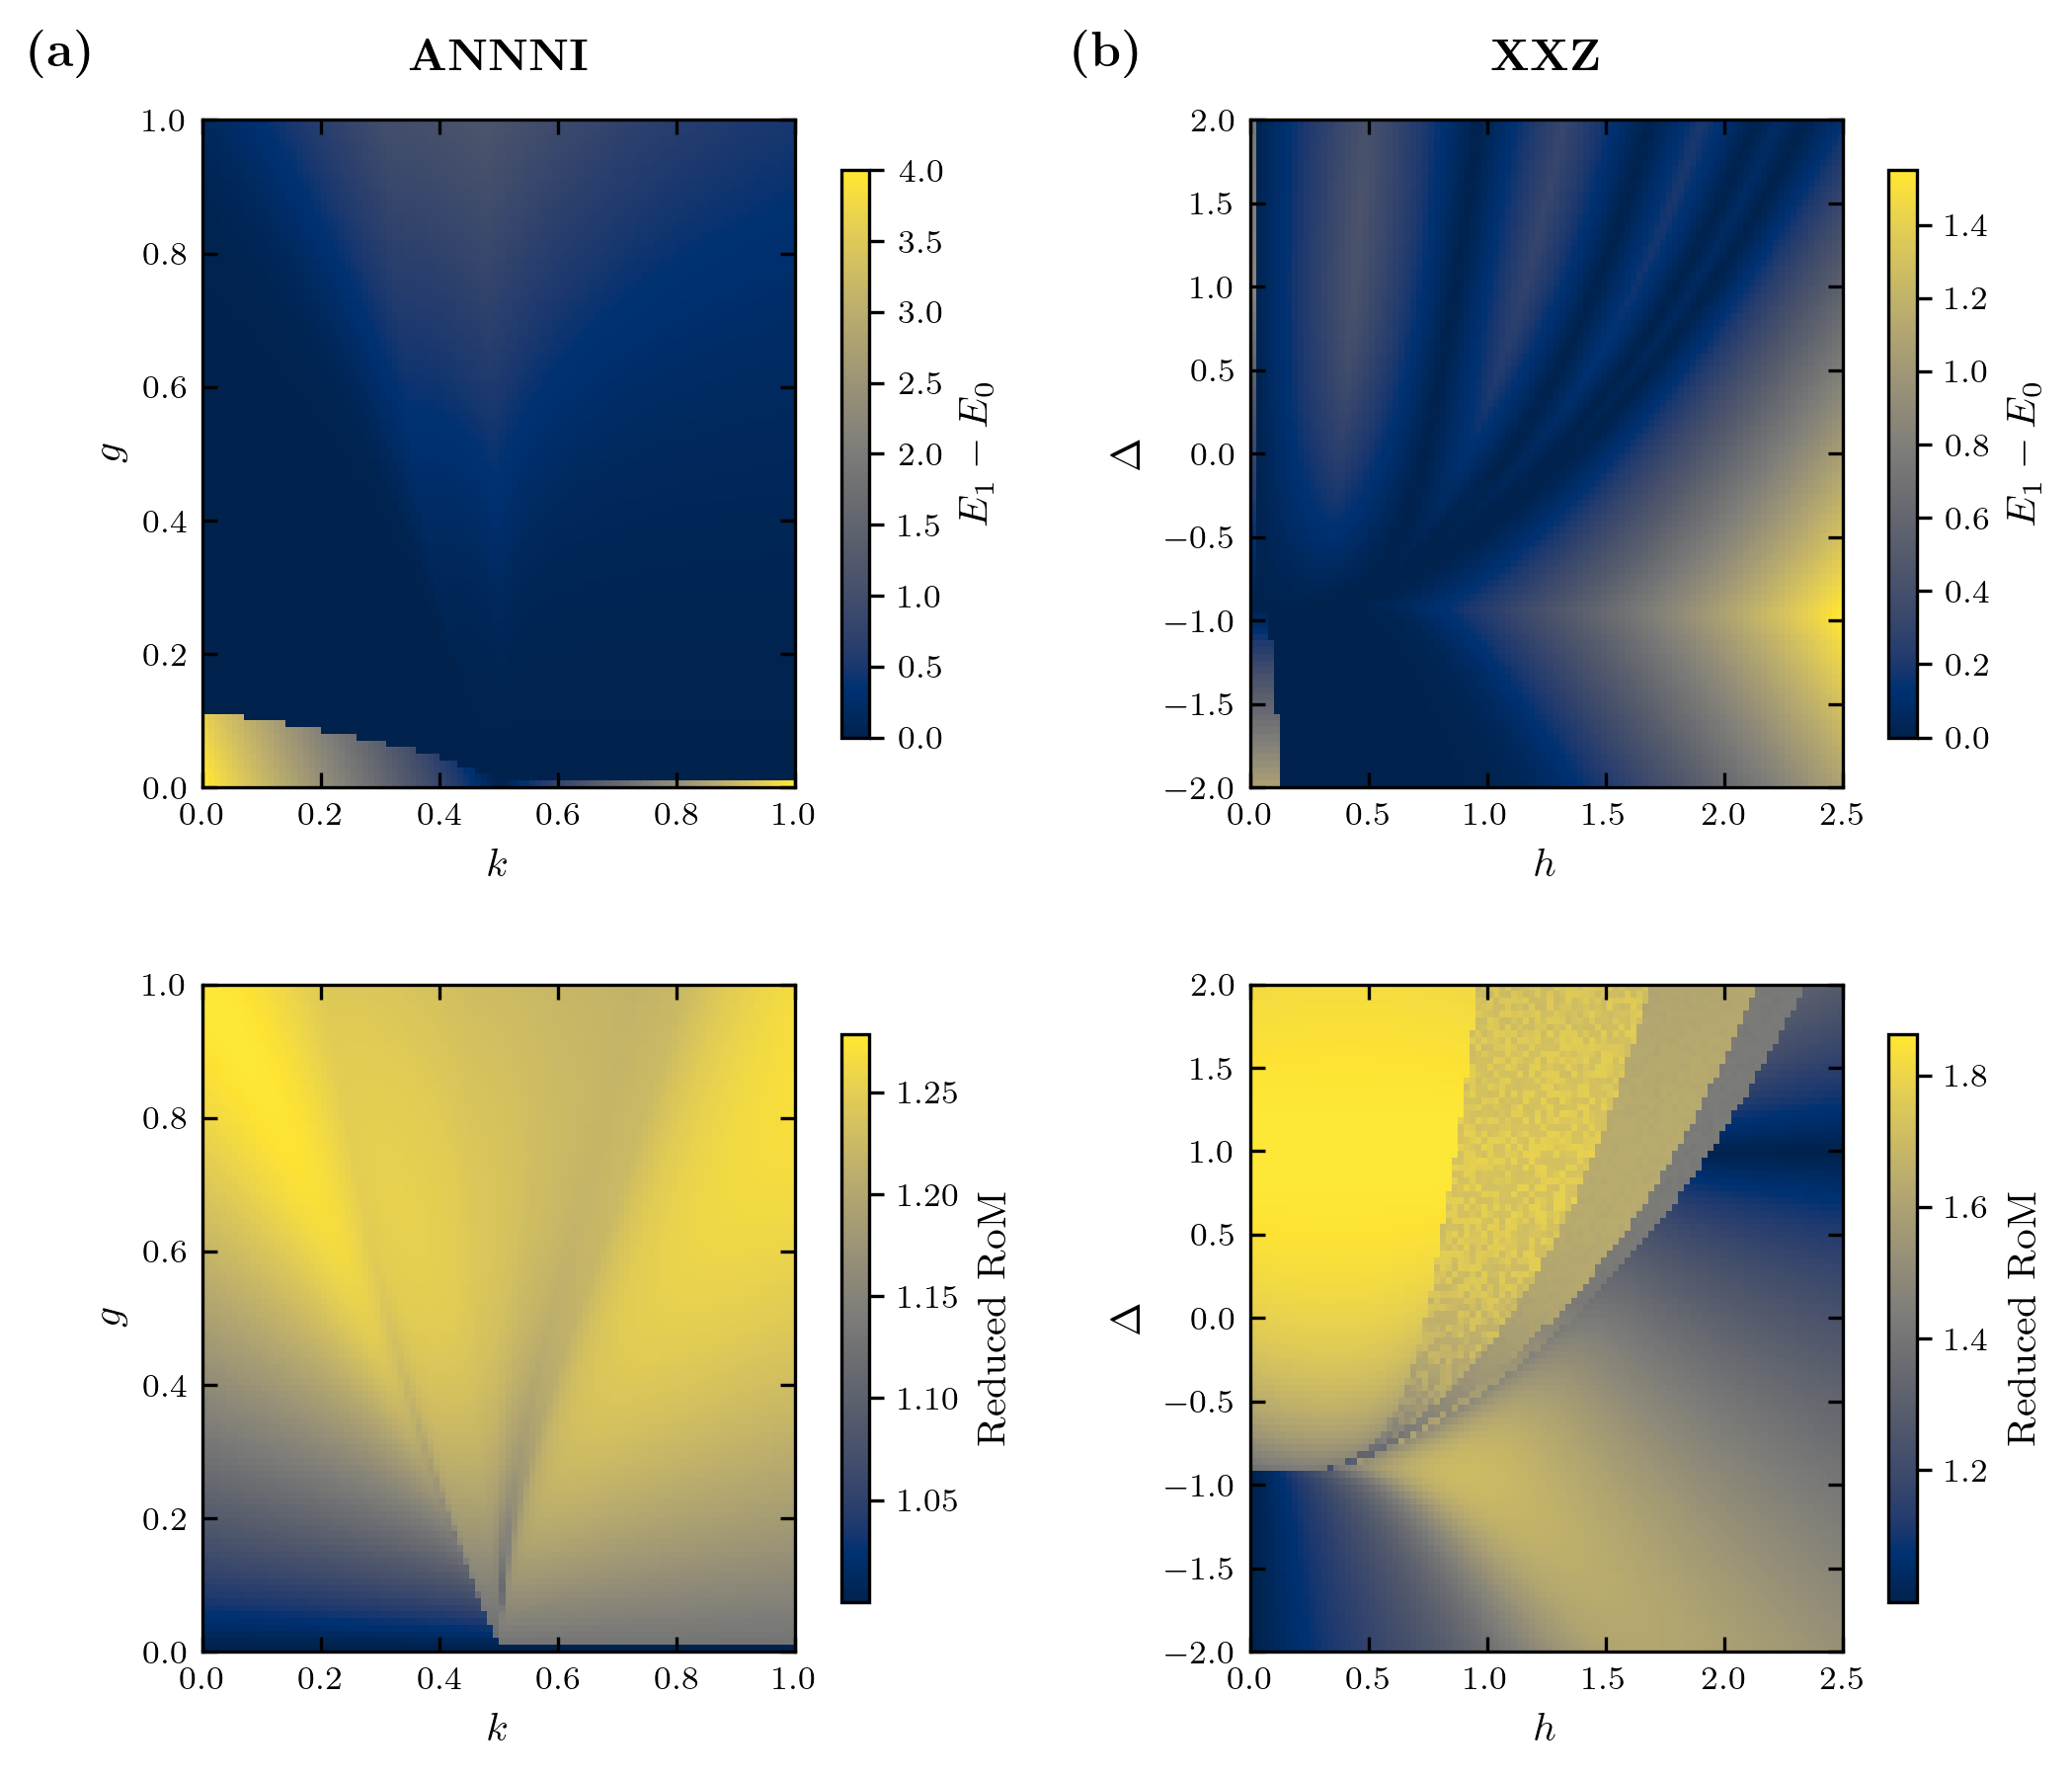

In [5]:
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.figsize": (7.0, 6.0),   # Largura de coluna dupla
    "axes.linewidth": 0.8,
    "figure.dpi": 300,
})

# ============================================================
# ORGANIZAÇÃO DOS DADOS (2 LINHAS x 2 COLUNAS)
# ============================================================
# Colunas: ANNNI (0), XXZ (1) | Linhas: Gaps (0), RoMs (1)
datasets = [
    [annni_gap, xxz_gap],   
    [annni_rrom, xxz_rrom]  
]

x_vals = [k_values, h_values]
y_vals = [g_values, delta_values]

x_labels = [r"$k$", r"$h$"]
y_labels = [r"$g$", r"$\Delta$"]
model_names = [r"ANNNI", r"XXZ"]
column_labels = [r"(a)", r"(b)"]

# ============================================================
# CONSTRUÇÃO DA FIGURA
# ============================================================
fig, axes = plt.subplots(2, 2, constrained_layout=True)

# wspace reduzido levemente para 0.12 para aproximar as colunas
fig.set_constrained_layout_pads(w_pad=0.1, h_pad=0.1, hspace=0.1, wspace=0.05)

for row in range(2):
    for col in range(2):
        ax = axes[row, col]
        data = datasets[row][col]
        
        # Colormap: 'magma' para Gaps, 'viridis' para RoM
        cmap_choice = "cividis" if row == 0 else "cividis"
        
        im = ax.imshow(
            data,
            extent=[x_vals[col].min(), x_vals[col].max(), y_vals[col].min(), y_vals[col].max()],
            origin="lower", 
            aspect="auto", 
            cmap=cmap_choice, 
            interpolation="nearest"
        )
        
        # --- TÍTULOS E IDENTIFICADORES DE COLUNA ---
        if row == 0:
            # Título do modelo centralizado
            ax.set_title(rf"\textbf{{{model_names[col]}}}", pad=12)
            
            # Identificador (a) ou (b) na quina superior esquerda do eixo
            # Usamos xycoords='axes fraction' e um pequeno offset negativo em x
            ax.annotate(rf"\textbf{{{column_labels[col]}}}", xy=(0, 1), xytext=(-25, 10),
                        xycoords='axes fraction', textcoords='offset points',
                        fontsize=12, ha='right', va='bottom')
        
        # --- EIXOS ---
        ax.set_xlabel(x_labels[col])
        ax.set_ylabel(y_labels[col])
        
        # Ticks padrão APS
        ax.tick_params(direction='in', top=True, right=True, which='both')
        
        # --- COLORBARS ---
        cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.04) 
        if row == 0:
            cbar.set_label(r"$E_1-E_0$")
        else:
            cbar.set_label(r"Reduced RoM")

# ============================================================
# FINALIZAÇÃO
# ============================================================
plt.savefig("ANNNI-and-XXZ.pdf", bbox_inches="tight")
plt.show()